In [1]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from scipy.stats import norm


# 1

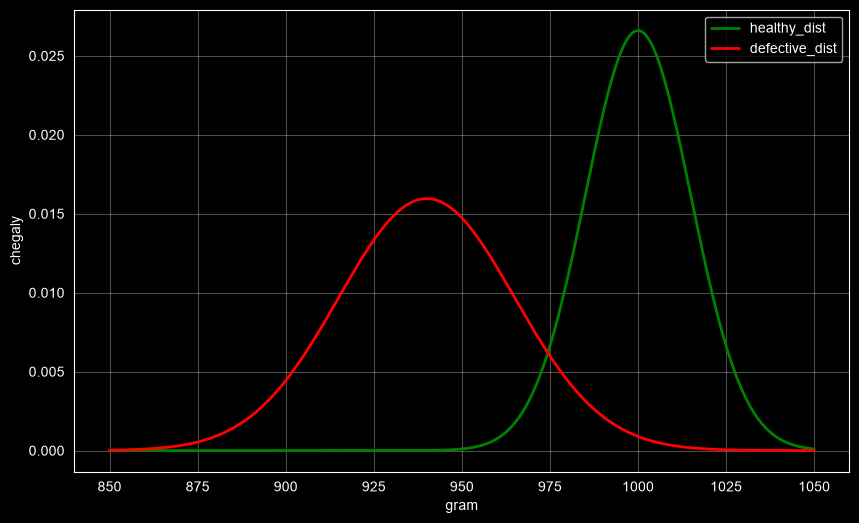

In [2]:
healthy_dist = norm(loc=1000, scale=15)
defective_dist = norm(loc=940, scale=25)

x = np.linspace(850, 1050, 1000)

healthy_pdf = healthy_dist.pdf(x)
defective_pdf = defective_dist.pdf(x)

plt.figure(figsize=(10, 6))
plt.plot(x, healthy_pdf, label='healthy_dist', color='green', linewidth=2)
plt.plot(x, defective_pdf, label='defective_dist', color='red', linewidth=2)
plt.xlabel('gram')
plt.ylabel('chegaly')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2

In [3]:
P_healthy = 0.92
P_defective = 0.08

x0 = 970
likelihood_healthy = healthy_dist.pdf(x0)  # p(x|healthy)
likelihood_defective = defective_dist.pdf(x0)  # p(x|defective)

posterior_numerator_healthy = P_healthy * likelihood_healthy
posterior_numerator_defective = P_defective * likelihood_defective

print(f"P(healthy) × p(x=970|healthy) = {posterior_numerator_healthy:.6f}")
print(f"P(defective) × p(x=970|defective) = {posterior_numerator_defective:.6f}")

if posterior_numerator_healthy > posterior_numerator_defective:
    print("healthy")
else:
    print("defective")

# normalize
evidence = posterior_numerator_healthy + posterior_numerator_defective
posterior_healthy = posterior_numerator_healthy / evidence
posterior_defective = posterior_numerator_defective / evidence

print(f"P(healthy|970) = {posterior_healthy:.4f}")
print(f"P(defective|970) = {posterior_defective:.4f}")

P(healthy) × p(x=970|healthy) = 0.003311
P(defective) × p(x=970|defective) = 0.000621
healthy
P(healthy|970) = 0.8420
P(defective|970) = 0.1580


# 4

k=1:
  train accuracy: 1.0000
  test accuracy: 0.9630

k=5:
  train accuracy: 0.9839
  test accuracy: 0.9444

k=15:
  train accuracy: 0.9758
  test accuracy: 0.9815



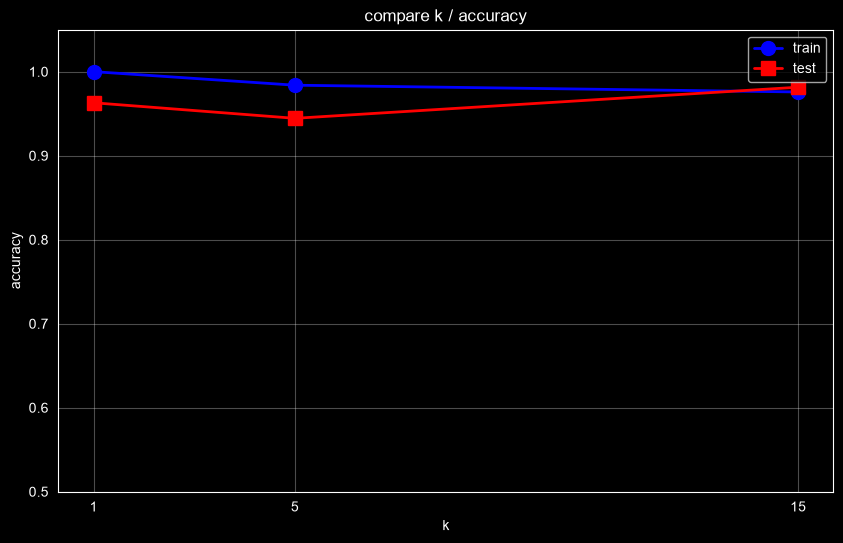

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X, y = load_wine(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

k_values = [1, 5, 15]
train_accuracies = []
test_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    train_acc = accuracy_score(y_train, knn.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, knn.predict(X_test_scaled))

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"k={k}:")
    print(f"  train accuracy: {train_acc:.4f}")
    print(f"  test accuracy: {test_acc:.4f}")
    print()

plt.figure(figsize=(10, 6))
plt.plot(k_values, train_accuracies, 'o-', label='train', color='blue', linewidth=2, markersize=10)
plt.plot(k_values, test_accuracies, 's-', label='test', color='red', linewidth=2, markersize=10)
plt.xlabel('k')
plt.ylabel('accuracy')
plt.title('compare k / accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.ylim(0.5, 1.05)
plt.show()

# 5

سه دلیل برای ضرورت استانداردسازی در KNN:

مقایسه‌پذیری ویژگی‌ها: KNN بر اساس فاصله (معمولاً فاصله اقلیدسی) کار می‌کند. اگر ویژگی‌ها مقیاس‌های متفاوتی داشته باشند (مثلاً یک ویژگی در بازه ۰-۱ و دیگری در بازه ۰-۱۰۰۰)، ویژگی با مقیاس بزرگتر بر فاصله تأثیر بیشتری خواهد داشت و عملاً ویژگی‌های با مقیاس کوچکتر نادیده گرفته می‌شوند. استانداردسازی همه ویژگی‌ها را به یک مقیاس قابل مقایسه می‌آورد.

تأثیر یکنواخت همه ویژگی‌ها: بدون استانداردسازی، الگوریتم به طور ناخودآگاه به ویژگی‌هایی با دامنه بزرگتر وزن بیشتری می‌دهد. مثلاً در داده‌های شراب، ویژگی‌هایی مثل 'proline' (که مقادیر بزرگتری دارد) بر 'malic_acid' (با مقادیر کوچکتر) غالب می‌شوند، در حالی که ممکن است هر دو به یک اندازه مهم باشند.

همگرایی بهتر: استانداردسازی باعث می‌شود که تابع فاصله به درستی عمل کند و همسایگی‌ها بر اساس ترکیب متوازنی از همه ویژگی‌ها تعیین شوند. این امر به ویژه در داده‌های با ابعاد بالا و ویژگی‌هایی با واحدهای مختلف (مثل میلی‌گرم در لیتر، درصد، pH و غیره) حیاتی است.


